In [2]:
# LabOne Q:
from laboneq.simple import *

# Helpers:
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_results
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import time
import os
import laboneq
print(laboneq.__version__)

2.51.0


In [3]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.22 14:18:48.300] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.08.22 14:18:48.303] INFO    VERSION: laboneq 2.51.0
[2025.08.22 14:18:48.305] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.22 14:18:48.311] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.22 14:18:48.318] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.08.22 14:18:48.322] INFO    Configuring the device setup
[2025.08.22 14:18:48.330] INFO    The device setup is configured


In [28]:
# frequency range of spectroscopy scan - around expected centre frequency as defined in qubit parameters
res_lo_freq = 7.2e9
qb_lo_freq = 3e9
res_freq = 7.148812e9
start_freq = -100e6 # actual_start_freq = central_freq - start_freq
stop_freq = 400e6

num_points = 3001 # stop - start / (num_points-1)
integration_time = 1e-5
num_averages = 9 # average number = 2^n, n_max = 17

measure_range = -35 # actual power = range (dBm) - 20log(amp)
measure_amp = 0.4
acquire_range = -35
acquire_amp = 0.8
drive_amp = 0.9

envelope_duration = 2.0e-6
sigma = 0.2
flat_duration = 1.0e-6


In [29]:
# pulse parameters and definitions
def create_readout_pulse(
    qubit, length=envelope_duration, amplitude=0.9, width=flat_duration, sigma=sigma
):
    readout_pulse = pulse_library.gaussian_square(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude,
        width=width,
        sigma=sigma,)
    return readout_pulse

drive_length = 1e-6

def create_drive_spec_pulse(qubit, length=drive_length, amplitude=drive_amp):
    pulse = pulse_library.const(
        uid=f"drive_spec_pulse_{qubit}", length=length, amplitude=amplitude
    )
    return pulse

def create_drive_freq_sweep(qubit, start_freq, stop_freq, num_points):
    return LinearSweepParameter(
        uid=f"drive_freq_{qubit}", start=start_freq, stop=stop_freq, count=num_points
    )

In [ ]:
# function that returns a qubit spectroscopy experiment- accepts frequency sweep range as parameter
def qubit_spectroscopy(freq_sweep, drive_pulse, readout_pulse):
    # Create qubit spectroscopy Experiment - uses qubit drive, readout drive and data acquisition lines
    exp_qspec = Experiment(
        uid="Qubit Spectroscopy",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    # inner loop - real-time averaging - QA in integration mode
    with exp_qspec.acquire_loop_rt(
        uid="freq_shots",
        count=2**num_averages,
        acquisition_type=AcquisitionType.INTEGRATION,
    ):
        with exp_qspec.sweep(uid="qfreq_sweep", parameter=freq_sweep):
            # qubit drive
            with exp_qspec.section(uid="qubit_excitation"):
                exp_qspec.play(signal="drive", pulse=drive_pulse)
            with exp_qspec.section(
                uid="readout_section", play_after="qubit_excitation"
            ):
                # play readout pulse on measure line
                exp_qspec.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_qspec.acquire(
                    signal="acquire",
                    handle="qb_spec",
                    kernel=readout_pulse,
                )
            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_qspec.section(uid="relax", length=1e-6):
                exp_qspec.reserve(signal="measure")

    return exp_qspec

In [31]:
# frequency range of spectroscopy scan - defined around expected qubit frequency as defined in qubit parameters
freq_sweep_q0 = create_drive_freq_sweep("q0", start_freq, stop_freq, num_points)

# experiment signal calibration for qubit 0
exp_calibration = Calibration()
exp_calibration["drive"] = SignalCalibration(
    oscillator = Oscillator(uid = "ch0_osc_0", frequency = freq_sweep_q0,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="ch0_lo", frequency = qb_lo_freq),
    range = -30)

exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = res_freq-res_lo_freq,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = res_lo_freq),
    range = -30)

exp_calibration["acquire"] = SignalCalibration(range = acquire_range, amplitude= acquire_amp)

# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "drive_line"
        ],
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map

# define experiment with frequency sweep for qubit 0
drive_pulse = create_drive_spec_pulse("q0")
readout_pulse = create_readout_pulse("q0", sigma=0.2, width=1e-6)

exp_qspec = qubit_spectroscopy(freq_sweep_q0, drive_pulse, readout_pulse)

# apply calibration and signal map for qubit 0
exp_qspec.set_calibration(exp_calibration)
exp_qspec.set_signal_map(signal_map_default("q0"))

In [ ]:
# compile the experiment on the open instrument session
compiled_qspec = session.compile(exp_qspec)
Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Qubit_Spectroscopy", compiled_qspec)

[2025.08.22 18:37:01.611] INFO    Starting LabOne Q Compiler run...
[2025.08.22 18:37:02.636] INFO    Schedule completed. [1.023 s]
[2025.08.22 18:37:04.640] INFO    Code generation completed for all AWGs. [2.002 s]
[2025.08.22 18:37:04.641] INFO    Completed compilation step 1 of 1. [3.027 s]
[2025.08.22 18:37:04.645] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.22 18:37:04.646] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.22 18:37:04.647] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.22 18:37:04.648] INFO      device_shfqc        0         10            0           1      8000  
[2025.08.22 18:37:04.648] INFO      device_shfqc_sg     1         23            2           1      4000  
[2025.08.22 18:37:04.649] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.22 18:37:04.649] INFO      TOTAL                         33 

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\Qubit_Spectroscopy_2025-08-22-18-37-04.html

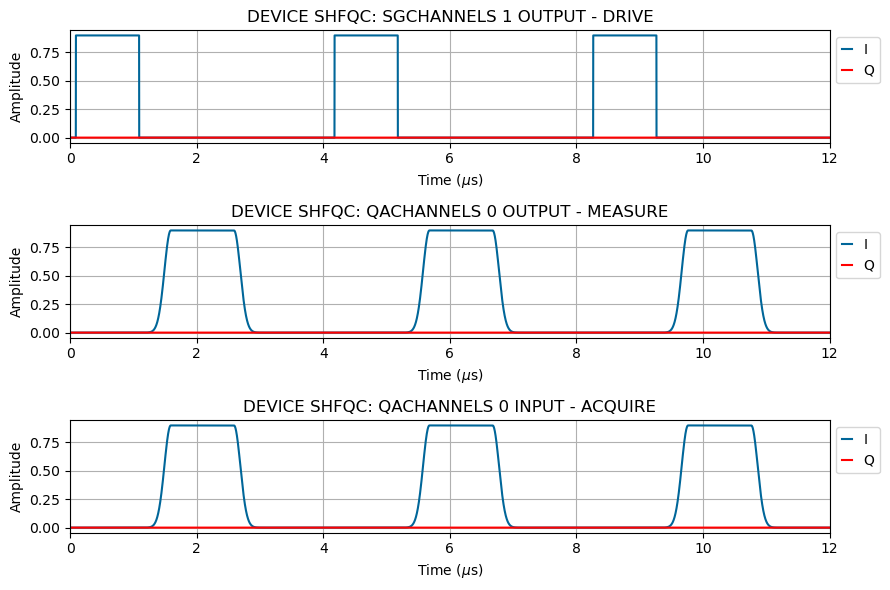

In [33]:
plot_simulation(compiled_qspec, start_time=0, length=12e-6)

In [34]:
# run the compiled experiemnt
qspec_results = session.run(compiled_qspec)
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)
save(qspec_results, f"Results/{timestamp}_qspec_results.json")
print(f"File saved as Results/{timestamp}_qspec_results.json")

[2025.08.22 18:37:08.702] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.22 18:37:08.707] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.22 18:37:08.710] INFO    Configuring the device setup
[2025.08.22 18:37:08.717] INFO    The device setup is configured
[2025.08.22 18:37:09.028] INFO    Starting near-time execution...
[2025.08.22 18:37:09.080] INFO    Estimated RT execution time: 6.28 s.
[2025.08.22 18:37:15.460] INFO    Finished near-time execution.
File saved as Results/20250822T183715_qspec_results.json


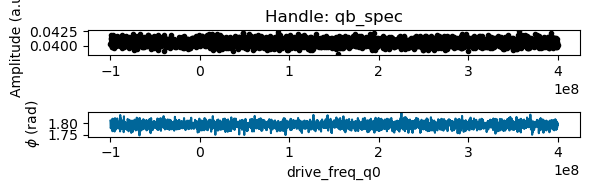

In [35]:
plot_results(qspec_results, phase=True)